# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

Before discussing the PCA its best to discuss how the data was formed.

series 1:  100 random numbers with mean of 2 and st dev of .5
series 2:  100 random numbers calculated as:  series 1 * (1 + random number around 0 with st dev of 0.1).
series 3:  100 random numbers calculates as:  series 1 * (1 + random number around 0 with st dev of 0.5).

The above info indicates that series 2 is tightly correlated with series 1 while series 3 is less tightly correlated (but still correlated as it was created from series 1 values) due to having been created with a higher st dev.

its also best to discuss the explained variance ratio and the actual components printed out below.

**the explained variance ratio shows the following:**

first component explains 80% of the variance in the data set.
second component explains 19% of the variance in the data set (in an orthogonal direction to pc1 of course, it will tell us something that PC1 doesn't)
third component explains 1% of the variance in the data set.  not much!

**the actual components show the following:**

first component:  all coefficients are positive so PC1 increases when all variables increase or vice versa.  the third series has a larger coefficient due to having higher variance.  PC1 will capture the magnitude of the data from a combination of all three series.

second component:  the coefficients for the first and second series is positive while the coefficient of the third series is negative.   these contrasting directions basically say the following:   how different is series 3 from series 1 and 2?

third component is only 1% so it not worth talking about for this purpose.

**Three Outliers in PCA graph**

The three outliers in the PCA graph are in the upper left so they are in the low end of PC1 score (negative in this instance) and in the high end of PC2 score (positive in this instance)

1st PC is low
2nd PC is high

**What does this mean about their values in series 1, 2, and 3?**

with a first PC being low it means that those outliers are low in all three series (since all three series move together in PC1 w the efficients having the same sign.  positive in this instace).
with a second PC being high is means that those outliers are high in series 1 and series 2 relative to series 3 (since PC2 captures the contrast betweeen series 1 and 2 with series 3)

**what can you say about series 3**

you can say something meaningful about series 3 because the second PC captures the difference between series 3 and the combination of series 1 and series 2.   since PC2 captures how series 3 deviates from the shared patterns of series 1 and series 2 (remember series 1 and 2 are more closely related than series 3 is due to how they were constructed).  so points that are high or low in PC2 represent unusual values in series 3 relative to the other two series.

**why can you say less about series 1 and series 2?**

since series 1 and 2 are more closely related (their PC1 scores are both very similar) the PC1 treats them as the same direction.  while this PCA tells us something about series 3 due PC2 highlighting the differences between series 3 and series 1 and 2, the PCA collapses series 1 and 2 into the same direction (since they are more closely related) so we lose some information about the relative values of series 1 and 2.  I didn't discuss this above but that information was preserved in PC3 (remember its only 1 percent of the explained variance so its not much info lost since those two components are so closely correlated

**advantages of PCA graph**

three dimensions of data is reduced to two dimensions while still containint 99% of the useful data. 

**disadvantages of PCA graph**

harder to interpret since the axes (Principle components) are combinations of the input series.
its difficult to determine exact values of series 1, 2, and 3 from the graph.
because series 1 and 2 are more closely correlated the PCA effectively merges them and makes it hard to distinguish between them or compare their relative values.

**does it show anything interesting**

it shows the general structure of the data and it shows the three outliers in th upper left.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

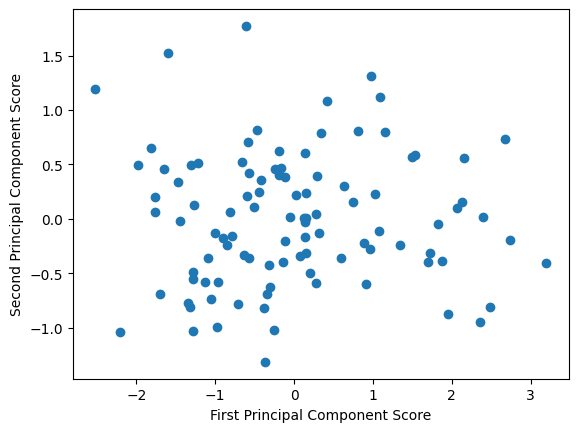

In [5]:


%pip install scikit-learn
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

here are the results of **PCA**:

PC1 = 47%
PC2 = 30%
PC3 = 15%

out of the six features in this PCA we can explain 47% of the variance using only the first principle component.    this is not high enough to use only one principle component to represent the data.   it would be necessary to use the top two principle components which combined would represent 77% of the variance in the data.

PC1:
VE_TOTAL = 0.46
PERSONS = 0.54
PERMVIT = 0.54
PEDS = -0.29
PERNOTMVIT = -0.28

high PC1 equals many vehicles and many people in vehicles while low PC1 indicates more pedestrian related crashes.

this matches the results from milestone 3.  PERSONS and PERMVIT are highly correlated as well as PEDS  and PERNOTMVIT.  PCA has combined both of those redundant variables into one dimension.

PC2:
PEDS = 0.64
PERNOTMVIT = 0.65

basically PC2 represents pedestrian or non-vehicle involvement.   High PC2 is pedestrian heavy crashes while low PC2 is mostly vehicle only crashes


**Linear regression** models were used to evaluate how well different groups of variables predict the number of fatalities. overall the models showed low predictive power, with the highest R2 value of 0.09. This indicates that the selected variables explain only a small portion of the variation in fatalities.

The model using crash size variables (number of vehicles and people involved) performed best, suggesting that larger crashes are somewhat associated with higher fatalities. However the relationship is still weak,  indicating that crash size alone does not strongly determine crash severity.

Models using pedestrian and time related variables performed very poorly.  giving R2 values close to zero. suggesting that these variables do not have strong linear relationships with fatalities. Although earlier analysis in milestone 3 showed patterns in time variables (such as increased fatalities at night or on weekends), these relationships are likely nonlinear and are not captured well by linear regression.

The combined model, which included all variables, did not significantly improve performance, indicating that the additional variables do not contribute much predictive power. This may be due to redundancy among variables or the influence of unobserved factors such as driver behavior, road conditions, or speed.  Those can be explore with more linear models or other models.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("accident.csv")

cols = ['FATALS', 'VE_TOTAL', 'VE_FORMS', 'PERSONS', 'PERMVIT', 'PEDS',
        'PERNOTMVIT', 'MONTH', 'DAY_WEEK', 'HOUR', 'MINUTE',
        'LATITUDE', 'LONGITUD']

df2 = df[cols].copy()

df2.loc[df2['HOUR'].isin([99]), 'HOUR'] = np.nan
df2.loc[df2['MINUTE'].isin([99]), 'MINUTE'] = np.nan
df2.loc[df2['LATITUDE'] > 90, 'LATITUDE'] = np.nan
df2.loc[df2['LONGITUD'] > 0, 'LONGITUD'] = np.nan   # longitude in US should usually be negative

df_num = df2.dropna()

print(df_num.shape)
df_num.head()

(38939, 13)


,FATALS,VE_TOTAL,VE_FORMS,PERSONS,PERMVIT,PEDS,PERNOTMVIT,MONTH,DAY_WEEK,HOUR,MINUTE,LATITUDE,LONGITUD
0,1,2,2,3,3,0,0,1,7,12.0,30.0,33.490967,-88.274083
1,2,2,2,5,5,0,0,1,7,16.0,40.0,32.087125,-86.064153
2,1,1,1,2,2,0,0,1,7,1.0,33.0,33.428331,-86.351994
3,1,1,1,1,1,0,0,1,1,14.0,46.0,32.216903,-86.400169
4,1,1,1,1,1,1,1,1,1,18.0,48.0,33.540281,-86.687389


In [7]:
print("Unique HOUR values:")
print(sorted(df['HOUR'].dropna().unique()))

print("\nUnique MINUTE values:")
print(sorted(df['MINUTE'].dropna().unique()))

Unique HOUR values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(99)]

Unique MINUTE values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(

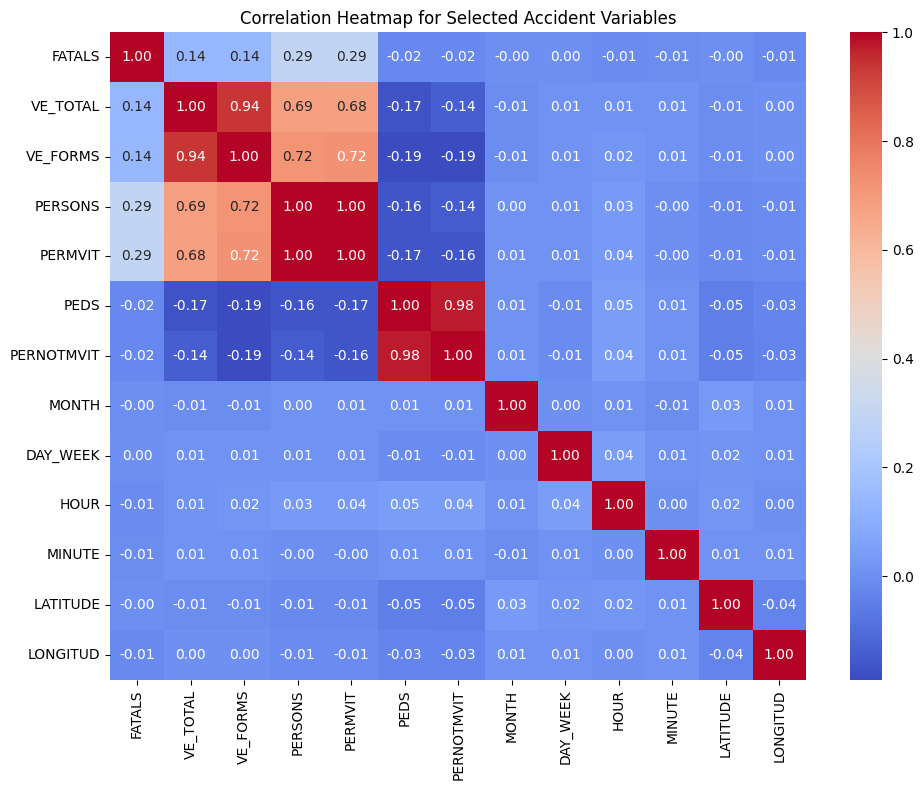

In [8]:
plt.figure(figsize=(10, 8))
corr = df_num.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap for Selected Accident Variables")
plt.tight_layout()
plt.show()

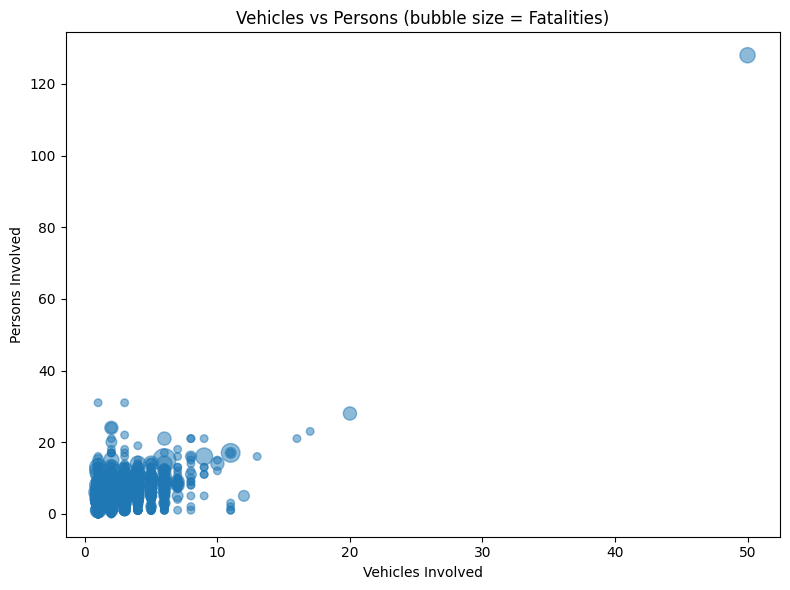

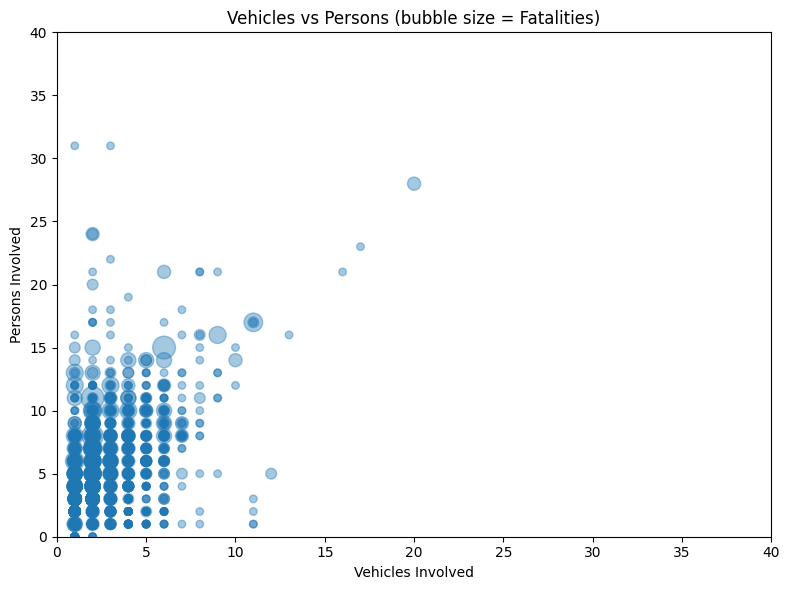

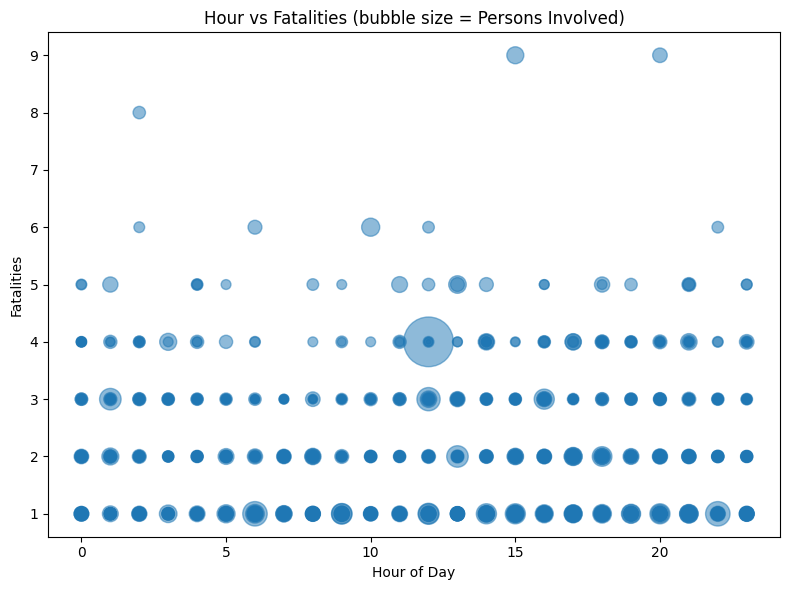

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(df_num['VE_TOTAL'],
            df_num['PERSONS'],
            s=df_num['FATALS'] * 30,
            alpha=0.5)

plt.xlabel("Vehicles Involved")
plt.ylabel("Persons Involved")
plt.title("Vehicles vs Persons (bubble size = Fatalities)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(df_num['VE_TOTAL'],
            df_num['PERSONS'],
            s=df_num['FATALS'] * 30,
            alpha=0.4)

plt.xlabel("Vehicles Involved")
plt.ylabel("Persons Involved")
plt.title("Vehicles vs Persons (bubble size = Fatalities)")

plt.xlim(0, 40)
plt.ylim(0, 40)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(df_num['HOUR'],
            df_num['FATALS'],
            s=df_num['PERSONS'] * 10,
            alpha=0.5)

plt.xlabel("Hour of Day")
plt.ylabel("Fatalities")
plt.title("Hour vs Fatalities (bubble size = Persons Involved)")
plt.tight_layout()
plt.show()

In [10]:
pca_cols = ['FATALS', 'VE_TOTAL', 'PERSONS', 'PERMVIT', 'PEDS', 'PERNOTMVIT']
pca_df = df_num[pca_cols].copy()

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=len(pca_cols))
pca.fit(pca_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nPrincipal component directions:")
print(pd.DataFrame(pca.components_, columns=pca_cols, index=[f'PC{i+1}' for i in range(len(pca_cols))]))

Explained variance ratio:
[4.76185863e-01 3.02304208e-01 1.51183166e-01 6.58491795e-02
 4.47758377e-03 7.08327228e-18]

Principal component directions:
           FATALS      VE_TOTAL   PERSONS   PERMVIT      PEDS  PERNOTMVIT
PC1  2.091701e-01  4.604976e-01  0.540244  0.541181 -0.286689   -0.277957
PC2  1.608964e-01  1.719514e-01  0.237172  0.229156  0.643573    0.649304
PC3  9.483300e-01 -2.836410e-01 -0.089400 -0.086525 -0.044907   -0.052177
PC4  1.761418e-01  8.228225e-01 -0.373939 -0.388908 -0.013704    0.025877
PC5  2.121659e-03  2.975764e-02 -0.243134  0.229996  0.668556   -0.663423
PC6  3.338574e-17 -1.213564e-15  0.667045 -0.665565  0.233348   -0.240046


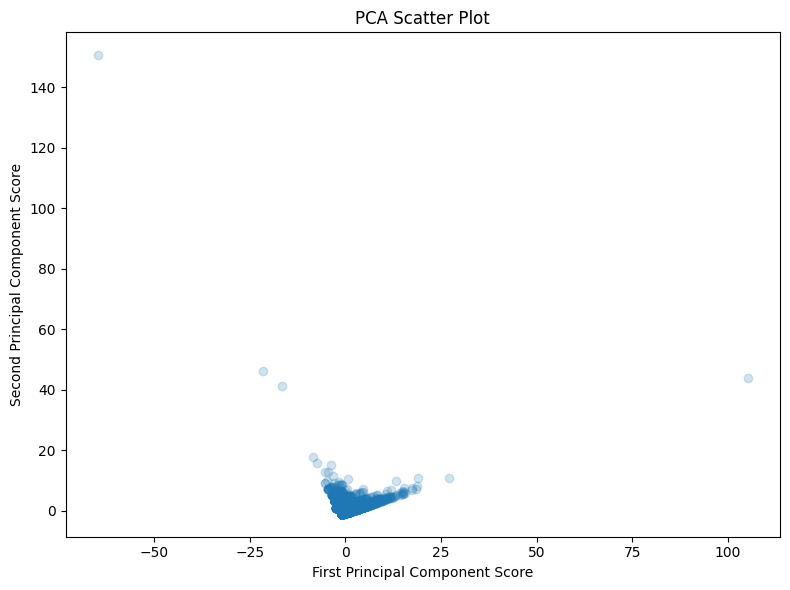

In [22]:
pca2 = PCA(n_components=2)
scores_2d = pca2.fit_transform(pca_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(scores_2d[:, 0], scores_2d[:, 1], alpha=0.2)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")
plt.title("PCA Scatter Plot")
plt.tight_layout()
plt.show()

In [25]:
pca1 = PCA(n_components=1)
scores_1d = pca1.fit_transform(pca_scaled)

print("variance captured by first principal component:")
print(pca1.explained_variance_ratio_[0])

print("Cumulative variance captured with first two principal components:")
print(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])

variance captured by first principal component:
0.476185862743775
Cumulative variance captured with first two principal components:
0.7784900704183699


In [26]:
# reconstruct using only first principal component
reconstructed_scaled = pca1.inverse_transform(scores_1d)

# convert back to original scale
reconstructed = scaler.inverse_transform(reconstructed_scaled)
reconstructed_df = pd.DataFrame(reconstructed, columns=pca_cols)

print(reconstructed_df.head())

     FATALS  VE_TOTAL   PERSONS   PERMVIT      PEDS  PERNOTMVIT
0  1.148221  1.933762  3.054153  3.043620  0.087420    0.097954
1  1.280757  2.645733  4.800373  4.788988 -0.236747   -0.225361
2  1.064354  1.483235  1.949165  1.939170  0.292550    0.302544
3  1.019962  1.244766  1.364282  1.354573  0.401127    0.410836
4  0.954688  0.894117  0.504260  0.494971  0.560781    0.570070


In [27]:
X1 = df_num[['VE_TOTAL', 'PERSONS', 'PERMVIT']]
y = df_num['FATALS']

model1 = LinearRegression()
model1.fit(X1, y)
pred1 = model1.predict(X1)

print("Model 1: VE_TOTAL, PERSONS, PERMVIT")
print("R^2:", r2_score(y, pred1))
print("RMSE:", np.sqrt(mean_squared_error(y, pred1)))
print("Coefficients:")
print(pd.Series(model1.coef_, index=X1.columns))

Model 1: VE_TOTAL, PERSONS, PERMVIT
R^2: 0.09033246938414541
RMSE: 0.3311963132796401
Coefficients:
VE_TOTAL   -0.046166
PERSONS     0.069046
PERMVIT     0.002797
dtype: float64


In [28]:
X2 = df_num[['PEDS', 'PERNOTMVIT']]
model2 = LinearRegression()
model2.fit(X2, y)
pred2 = model2.predict(X2)

print("Model 2: PEDS, PERNOTMVIT")
print("R^2:", r2_score(y, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y, pred2)))
print("Coefficients:")
print(pd.Series(model2.coef_, index=X2.columns))

Model 2: PEDS, PERNOTMVIT
R^2: 0.0006897915229464591
RMSE: 0.34713172708758966
Coefficients:
PEDS         -0.044294
PERNOTMVIT    0.031257
dtype: float64


In [29]:
X3 = df_num[['MONTH', 'DAY_WEEK', 'HOUR', 'MINUTE']]
model3 = LinearRegression()
model3.fit(X3, y)
pred3 = model3.predict(X3)

print("Model 3: MONTH, DAY_WEEK, HOUR, MINUTE")
print("R^2:", r2_score(y, pred3))
print("RMSE:", np.sqrt(mean_squared_error(y, pred3)))
print("Coefficients:")
print(pd.Series(model3.coef_, index=X3.columns))

Model 3: MONTH, DAY_WEEK, HOUR, MINUTE
R^2: 0.000206888390122284
RMSE: 0.3472155903117568
Coefficients:
MONTH      -0.000067
DAY_WEEK    0.000406
HOUR       -0.000569
MINUTE     -0.000166
dtype: float64


In [30]:
X4 = df_num[['VE_TOTAL', 'PERSONS', 'PERMVIT', 'PEDS', 'PERNOTMVIT', 'MONTH', 'DAY_WEEK', 'HOUR']]
model4 = LinearRegression()
model4.fit(X4, y)
pred4 = model4.predict(X4)

print("Model 4: Combined")
print("R^2:", r2_score(y, pred4))
print("RMSE:", np.sqrt(mean_squared_error(y, pred4)))
print("Coefficients:")
print(pd.Series(model4.coef_, index=X4.columns))

Model 4: Combined
R^2: 0.09124135123094712
RMSE: 0.3310308168021353
Coefficients:
VE_TOTAL     -0.045461
PERSONS       0.048870
PERMVIT       0.023564
PEDS         -0.007017
PERNOTMVIT    0.018289
MONTH        -0.000312
DAY_WEEK      0.000032
HOUR         -0.001162
dtype: float64


In [31]:
results = pd.DataFrame({
    'Model': ['Crash size', 'Pedestrian related', 'Time related', 'Combined'],
    'R2': [
        r2_score(y, pred1),
        r2_score(y, pred2),
        r2_score(y, pred3),
        r2_score(y, pred4)],
    'RMSE': [
        np.sqrt(mean_squared_error(y, pred1)),
        np.sqrt(mean_squared_error(y, pred2)),
        np.sqrt(mean_squared_error(y, pred3)),
        np.sqrt(mean_squared_error(y, pred4))]})

print(results)

                Model        R2      RMSE
0          Crash size  0.090332  0.331196
1  Pedestrian related  0.000690  0.347132
2        Time related  0.000207  0.347216
3            Combined  0.091241  0.331031


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

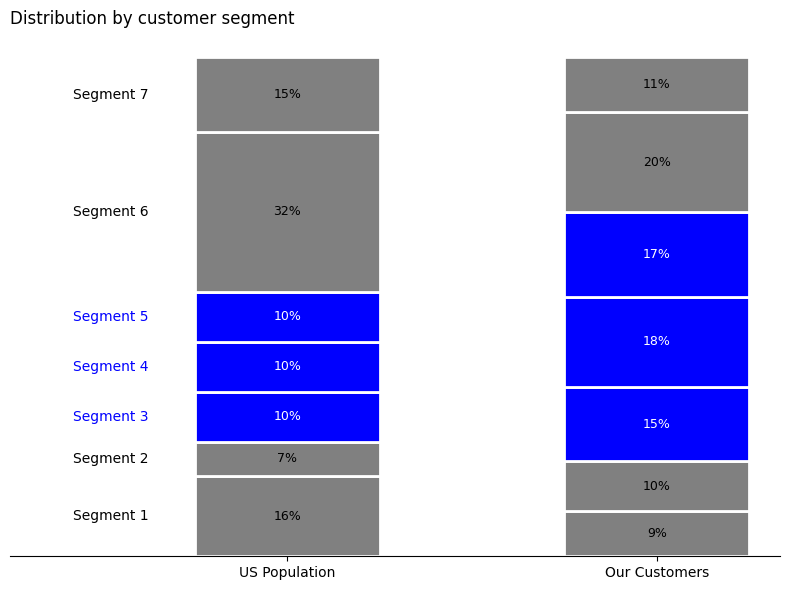

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Data
us_population = np.array([16, 7, 10, 10, 10, 32, 15])
our_customers = np.array([9, 10, 15, 18, 17, 20, 11])

labels = ["US Population", "Our Customers"]

us_pct = us_population / us_population.sum() * 100
cust_pct = our_customers / our_customers.sum() * 100

x = [0, 1.2]
bar_width = 0.6

colors = ['gray', 'gray', 'blue', 'blue', 'blue', 'gray', 'gray']

fig, ax = plt.subplots(figsize=(8, 6))

bottom = np.zeros(2)
segment_centers = []

for i in range(7):
    values = [us_pct[i], cust_pct[i]]

    bars = ax.bar(
        x,
        values,
        width=bar_width,
        bottom=bottom,
        color=colors[i],
        edgecolor='white',
        linewidth=2)

    center = bottom[0] + values[0] / 2
    segment_centers.append(center)

    for j in range(len(bars)):
        height = values[j]
        if height > 3:
            ax.text(
                x[j],
                bottom[j] + height / 2,
                f"{height:.0f}%",
                ha='center',
                va='center',
                color='white' if colors[i] == 'blue' else 'black',
                fontsize=9)

    bottom += values

for i in range(7):
    ax.text(
        -0.45,
        segment_centers[i],
        f"Segment {i+1}",
        ha='right',
        va='center',
        fontsize=10,
        color='blue' if i in [2, 3, 4] else 'black')


ax.set_title("Distribution by customer segment", loc='left')

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_yticks([])
ax.set_ylabel("")

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)

ax.set_xlim(-0.9, 1.6)

plt.tight_layout()
plt.show()